# 2 — DSPy prompt optimization for the judge

Notebook 1 showed where the judge disagrees with us. This notebook tries to *fix* the disagreement by optimizing the judge's prompt against the gold set.

## The setup, in one paragraph

We wrap the rubric judge as a `dspy.Module` whose forward pass takes `(question, answer, reference)` and returns `(correctness, faithfulness, overall)`. DSPy treats the prompt and any few-shot exemplars as the *thing being learned*, and uses our gold set as the training signal. The metric is a smooth distance from the human-supplied band — 1.0 if the judge falls inside `[expected_lo, expected_hi]`, decaying to 0 as it strays.

## Train/test discipline

We split **by group, not by item**. Paired items that share a question (B1/B2/B3 — same question, three different answers) stay together so the optimizer can see the contrast on the train side. With 32 items in 15 groups, a 50/50 split gives ~16 train / ~16 test items. **The test set is never shown to the optimizer.**

## Honest expectations

With only ~16 training items, this is a *probe of the methodology*, not a deployment-grade judge. We're looking for two things:
1. Does test-set agreement go up at all? (sanity check that the metric and signature work.)
2. Does the bias on `honesty_vs_fabrication` and `refusal_mode_equivalence` shrink? Those are the probes we actually care about.

If we see no movement, the gold set needs to grow before we tune knobs.

In [1]:
import _path_setup  # noqa: F401

import json
import os
import random
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

import dspy

load_dotenv()
assert os.environ.get("OPENROUTER_API_KEY"), "set OPENROUTER_API_KEY in .env"

DATA = Path("data")
GOLD = DATA / "judge_gold_set.jsonl"

items = [json.loads(l) for l in GOLD.read_text().splitlines() if l.strip()]
print(f"Loaded {len(items)} items in {len({i['group'] for i in items})} groups")

# Route DSPy through OpenRouter via litellm. The 'openrouter/<slug>' prefix
# tells litellm which provider to use; api_key + api_base do the rest.
STUDENT_SLUG = "openai/gpt-5.4-mini"  # cheap; the model we'd actually deploy
lm = dspy.LM(
    f"openrouter/{STUDENT_SLUG}",
    api_key=os.environ["OPENROUTER_API_KEY"],
    api_base="https://openrouter.ai/api/v1",
    temperature=0.0,
    max_tokens=2048,
)
dspy.configure(lm=lm)
print(f"DSPy configured with student={STUDENT_SLUG}")

Loaded 32 items in 15 groups
DSPy configured with student=openai/gpt-5.4-mini


In [2]:
class JudgeRubric(dspy.Signature):
    """Score an answer to a question on a 0-5 rubric.

    Definitions:
      - correctness: how factually correct the answer is vs. the reference (0=wrong, 5=fully correct).
      - faithfulness: whether the answer is grounded in the reference and does not fabricate (0=fabricated, 5=fully grounded).
      - overall: a single holistic 0-5 score that weighs correctness and faithfulness, plus completeness and clarity.

    Penalize fabricated content even if it sounds plausible. Reward honest acknowledgment
    that information is not available when that is the correct answer. Do not reward verbose
    formatting if it does not add information.
    """

    question: str = dspy.InputField(desc="the question being answered")
    answer: str = dspy.InputField(desc="the candidate answer to score")
    reference: str = dspy.InputField(desc="reference description of the correct answer")

    correctness: float = dspy.OutputField(desc="0.0-5.0")
    faithfulness: float = dspy.OutputField(desc="0.0-5.0")
    overall: float = dspy.OutputField(desc="0.0-5.0")


judge_module = dspy.ChainOfThought(JudgeRubric)
print('signature + module ready')

signature + module ready


In [3]:
# Convert gold items to dspy.Example. Inputs are the three fields the model sees;
# the rest (expected band, probe, group) ride along for the metric and split logic.
all_examples = []
for it in items:
    ex = dspy.Example(
        question=it["question"],
        answer=it["answer"],
        reference=it.get("reference") or "",
        expected_lo=it["expected_overall_min"],
        expected_hi=it["expected_overall_max"],
        probe=it["probe"],
        group=it["group"],
        item_id=it["id"],
    ).with_inputs("question", "answer", "reference")
    all_examples.append(ex)

# Group-aware split. Shuffle group ids deterministically, take half for train.
rng = random.Random(42)
groups = sorted({ex.group for ex in all_examples})
rng.shuffle(groups)
train_groups = set(groups[: len(groups) // 2])
trainset = [ex for ex in all_examples if ex.group in train_groups]
testset = [ex for ex in all_examples if ex.group not in train_groups]

print(f"train: {len(trainset)} items in {len(train_groups)} groups")
print(f"test:  {len(testset)} items in {len(groups) - len(train_groups)} groups")
print("\ntrain probe distribution:", pd.Series([e.probe for e in trainset]).value_counts().to_dict())
print("test probe distribution: ", pd.Series([e.probe for e in testset]).value_counts().to_dict())

train: 13 items in 7 groups
test:  19 items in 8 groups

train probe distribution: {'tone_vs_correctness': 4, 'length_bias': 3, 'refusal_mode_equivalence': 2, 'ground_truth_sanity': 2, 'specificity': 2}
test probe distribution:  {'honesty_vs_fabrication': 6, 'ground_truth_sanity': 4, 'citation_presence': 4, 'format_vs_verbosity': 3, 'refusal_mode_equivalence': 2}


In [4]:
# Smooth distance-to-band. 1.0 if inside, decays linearly to 0 over a 2.5-point window outside.
# Probe-weighted so the optimizer chases the biases we actually care about.
PROBE_WEIGHT = {
    "honesty_vs_fabrication": 2.0,
    "refusal_mode_equivalence": 2.0,
    "tone_vs_correctness": 1.5,
    "ground_truth_sanity": 1.0,
    "specificity": 1.0,
    "citation_presence": 1.0,
    "format_vs_verbosity": 0.5,  # we DON'T want the optimizer to chase format consistency hard
    "length_bias": 0.5,
}

def band_score(pred_overall: float, lo: float, hi: float) -> float:
    if pred_overall is None:
        return 0.0
    if lo <= pred_overall <= hi:
        return 1.0
    dist = min(abs(pred_overall - lo), abs(pred_overall - hi))
    return max(0.0, 1.0 - dist / 2.5)

def metric(gold, pred, trace=None) -> float:
    try:
        score = band_score(float(pred.overall), gold.expected_lo, gold.expected_hi)
    except (TypeError, ValueError, AttributeError):
        return 0.0
    return score * PROBE_WEIGHT.get(gold.probe, 1.0)

print('metric defined. weight summary:')
for p, w in sorted(PROBE_WEIGHT.items(), key=lambda kv: -kv[1]):
    print(f'  {p:<28s} x{w}')

metric defined. weight summary:
  honesty_vs_fabrication       x2.0
  refusal_mode_equivalence     x2.0
  tone_vs_correctness          x1.5
  ground_truth_sanity          x1.0
  specificity                  x1.0
  citation_presence            x1.0
  format_vs_verbosity          x0.5
  length_bias                  x0.5


In [5]:
# Stock baseline: unoptimized judge_module on the test set.
# We capture per-item predictions so we can compare to the optimized run cell-for-cell.
def evaluate(module, examples, label):
    rows = []
    for ex in examples:
        try:
            pred = module(question=ex.question, answer=ex.answer, reference=ex.reference)
            overall = float(pred.overall)
            err = ''
        except Exception as e:
            overall = None
            err = f'{type(e).__name__}: {e}'[:120]
        in_band = (overall is not None
                   and ex.expected_lo <= overall <= ex.expected_hi)
        rows.append({
            'variant': label, 'item_id': ex.item_id, 'probe': ex.probe, 'group': ex.group,
            'expected_lo': ex.expected_lo, 'expected_hi': ex.expected_hi,
            'overall': overall, 'in_band': in_band, 'error': err,
        })
        flag = '  ' if in_band else '!!'
        score_s = f'{overall:.2f}' if overall is not None else 'ERR'
        print(f"  {flag} [{label:<10s}] {ex.item_id:<32s} exp {ex.expected_lo}-{ex.expected_hi}  judge={score_s}")
    return pd.DataFrame(rows)

print('=== stock baseline on test set ===')
df_stock = evaluate(judge_module, testset, 'stock')
stock_agree = df_stock['in_band'].mean()
print(f"\nstock agreement on test: {stock_agree:.1%}")

=== stock baseline on test set ===
     [stock     ] A1_correct_easy                  exp 4.3-5.0  judge=5.00
     [stock     ] A2_confidently_wrong             exp 0.0-1.5  judge=0.00
     [stock     ] A3_partial_correct               exp 2.0-3.0  judge=2.00
     [stock     ] A4_empty                         exp 0.0-1.5  judge=1.00
     [stock     ] B1_honest_no_corpus              exp 4.5-5.0  judge=4.50
     [stock     ] B2_fabricated_plausible          exp 0.0-1.5  judge=0.00
     [stock     ] B3_lazy_idk                      exp 1.5-2.5  judge=2.50
     [stock     ] C1_tight_correct                 exp 4.3-5.0  judge=5.00
     [stock     ] C2_verbose_correct               exp 4.3-5.0  judge=5.00
  !! [stock     ] C3_padded_filler                 exp 4.0-4.8  judge=5.00
     [stock     ] D1_with_citations                exp 4.3-5.0  judge=4.70
  !! [stock     ] D2_no_citations                  exp 3.8-4.7  judge=5.00
     [stock     ] B4_honest_searched_graphrag      exp 4.5-5.0  j

In [6]:
# Simple optimizer: BootstrapFewShotWithRandomSearch.
# - Bootstraps few-shot demos by running the student on training items, keeping the
#   ones that score well under our metric.
# - Random-searches over candidate demo selections, scoring each program on a held-out
#   slice of the train set.
# Cost is roughly num_candidates * len(trainset) calls. Keep it modest first time.
from dspy.teleprompt import BootstrapFewShotWithRandomSearch

optimizer = BootstrapFewShotWithRandomSearch(
    metric=metric,
    max_bootstrapped_demos=4,
    max_labeled_demos=4,
    num_candidate_programs=6,
    num_threads=4,
)

print('optimizing... (will print progress)')
optimized_judge = optimizer.compile(judge_module, trainset=trainset)
print('done')

Going to sample between 1 and 4 traces per predictor.
Will attempt to bootstrap 6 candidate sets.
optimizing... (will print progress)
Average Metric: 14.30 / 13 (110.0%): 100%|██████████| 13/13 [00:00<00:00, 1124.57it/s]

2026/05/07 16:04:35 INFO dspy.evaluate.evaluate: Average Metric: 14.3 / 13 (110.0%)



New best score: 110.0 for seed -3
Scores so far: [110.0]
Best score so far: 110.0
Average Metric: 14.30 / 13 (110.0%): 100%|██████████| 13/13 [00:00<00:00, 1637.07it/s]

2026/05/07 16:04:35 INFO dspy.evaluate.evaluate: Average Metric: 14.3 / 13 (110.0%)



Scores so far: [110.0, 110.0]
Best score so far: 110.0


...


New best score: 110.46 for seed 4
Scores so far: [110.0, 110.0, 110.0, 108.15, 106.92, 106.92, 105.08, 110.46]
Best score so far: 110.46


 23%|██▎       | 3/13 [00:00<00:00, 38.13it/s]


Bootstrapped 3 full traces after 3 examples for up to 1 rounds, amounting to 3 attempts.
Average Metric: 14.30 / 13 (110.0%): 100%|██████████| 13/13 [00:00<00:00, 574.97it/s]

2026/05/07 16:04:36 INFO dspy.evaluate.evaluate: Average Metric: 14.3 / 13 (110.0%)



Scores so far: [110.0, 110.0, 110.0, 108.15, 106.92, 106.92, 105.08, 110.46, 110.0]
Best score so far: 110.46
9 candidate programs found.
done


In [7]:
print('=== optimized judge on test set ===')
df_opt = evaluate(optimized_judge, testset, 'optimized')
opt_agree = df_opt['in_band'].mean()
print(f"\noptimized agreement on test: {opt_agree:.1%}  (was {stock_agree:.1%})")

=== optimized judge on test set ===
     [optimized ] A1_correct_easy                  exp 4.3-5.0  judge=4.90
     [optimized ] A2_confidently_wrong             exp 0.0-1.5  judge=0.00
     [optimized ] A3_partial_correct               exp 2.0-3.0  judge=2.60


     [optimized ] A4_empty                         exp 0.0-1.5  judge=0.80
     [optimized ] B1_honest_no_corpus              exp 4.5-5.0  judge=4.60
     [optimized ] B2_fabricated_plausible          exp 0.0-1.5  judge=0.00
     [optimized ] B3_lazy_idk                      exp 1.5-2.5  judge=2.00
     [optimized ] C1_tight_correct                 exp 4.3-5.0  judge=5.00
     [optimized ] C2_verbose_correct               exp 4.3-5.0  judge=4.90
  !! [optimized ] C3_padded_filler                 exp 4.0-4.8  judge=5.00
  !! [optimized ] D1_with_citations                exp 4.3-5.0  judge=4.00
  !! [optimized ] D2_no_citations                  exp 3.8-4.7  judge=5.00
  !! [optimized ] B4_honest_searched_graphrag      exp 4.5-5.0  judge=4.40
     [optimized ] B5_fabricated_graphrag           exp 0.0-1.5  judge=0.00
     [optimized ] B6_lazy_idk_graphrag             exp 1.0-2.5  judge=1.50
  !! [optimized ] D3_with_citations_chunking       exp 4.3-5.0  judge=4.00
  !! [optimized ] D4_no_c

In [8]:
# Side-by-side headline numbers.
df_all = pd.concat([df_stock, df_opt], ignore_index=True)
headline = (df_all.groupby('variant')
                  .agg(n=('item_id', 'count'),
                       agreement_pct=('in_band', 'mean'),
                       n_errors=('error', lambda s: (s != '').sum()))
                  .assign(agreement_pct=lambda d: (d['agreement_pct'] * 100).round(1)))
headline

,n,agreement_pct,n_errors
variant,,,
optimized,19,63.2,0
stock,19,73.7,0


## Did optimization actually move the needle? Wilson + McNemar

A bare headline like "78% → 84%" is not enough on a 19-item test set. Two specific risks, two specific tools.

### Wilson confidence interval — "is this rate even pinned down?"

When you compute an accuracy from a small `n`, the *point estimate* hides how loose the underlying rate is. The standard normal-approximation CI (`p ± 1.96·√(p(1-p)/n)`) breaks badly when `n` is small or when `p` is near 0 or 1 — it can return intervals that go below 0 or above 1, and it misses coverage. Wilson's interval fixes both: it's derived by inverting a score test instead of a Wald test, so it stays inside [0, 1] and gives correct coverage at small `n`.

> **Tiny example.** 5 correct out of 6 trials.
> - Naive: `83.3% ± 30 pp`, range `[53%, 113%]` ← nonsense
> - Wilson 95% CI: `[44%, 97%]` ← honest about how little we know

In this notebook we report Wilson CIs on both `stock` and `optimized` agreement. **If the two intervals overlap heavily, the headline delta is inside noise** — don't ship a claim from it.

### McNemar's test — "did optimization fix items, or just shuffle errors?"

Wilson tells us how precisely each rate is measured *independently*. But these two evaluations are paired: the same 19 items run through both judges. The interesting question isn't "are the two marginal rates different" — it's "**on items where the two disagreed, did optimization win more often than it lost?**"

Build the 2×2 paired contingency table:

|  | opt correct | opt wrong |
|---|---|---|
| **stock correct** | a (both right) | b (regressions) |
| **stock wrong** | c (fixes) | d (both wrong) |

The diagonals `a` and `d` are concordant — they tell us nothing about whether optimization helped. McNemar conditions only on the discordant pairs `b` and `c`. Under the null hypothesis "optimization has no effect," each discordant pair is a fair coin flip: `b` and `c` should be roughly equal. The exact binomial McNemar test asks: given `b + c` discordant pairs, how surprising is the observed split?

> **Tiny example.** 19 items. Concordant: 12 both right, 5 both wrong. Discordant: `c=2` fixes, `b=0` regressions.
> - Headline: 14/19 → 16/19 (+10.5 pp). Looks like a clear win.
> - McNemar exact, two-sided: `p = 0.50`. Two coin flips both landing heads — happens 25% of the time. Not significant.
> - Verdict: it could be real, but with this much data we can't distinguish "real fix" from "lucky shuffle."

We use `exact=True` because `b + c` is small here (typically < 10). The chi-square approximation McNemar usually uses is unreliable below ~25 discordant pairs.

### How to read the cell below

- **`fixes_c >> regressions_b` and `mcnemar_p < 0.05`** → real, paired win. Optimization is doing something.
- **`fixes_c ≈ regressions_b`** → optimizer shuffled errors around. Headline delta, even if positive, is meaningless.
- **CIs overlap heavily and `mcnemar_p > 0.05`** → result is noise at this gold-set size. Grow the gold set before tuning knobs.

In [9]:
# Significance check: did optimization actually move the needle, or did it just
# shuffle errors around? With n this small, a bare "78% -> 84%" headline is not
# enough -- we want (a) a confidence interval on each rate, and (b) a paired
# test that conditions on the same items.
#
#   - Wilson CI: better than the normal approx for small n / proportions near 0/1.
#   - Exact McNemar: paired binary test on discordant pairs only. The "exact"
#     binomial form is the right call when b + c is small (which it will be here).

from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.proportion import proportion_confint

paired = (df_stock[['item_id', 'in_band']]
          .rename(columns={'in_band': 'stock'})
          .merge(df_opt[['item_id', 'in_band']]
                 .rename(columns={'in_band': 'optimized'}),
                 on='item_id'))

# 2x2 paired contingency table.
#   a = both correct, d = both wrong (concordant -- McNemar ignores these)
#   b = stock correct, optimized wrong  (regressions)
#   c = stock wrong,   optimized correct (fixes)
a = int(((paired['stock']) & (paired['optimized'])).sum())
b = int(((paired['stock']) & (~paired['optimized'])).sum())
c = int(((~paired['stock']) & (paired['optimized'])).sum())
d = int(((~paired['stock']) & (~paired['optimized'])).sum())
n = a + b + c + d

table = pd.DataFrame(
    [[a, b], [c, d]],
    index=['stock correct', 'stock wrong'],
    columns=['opt correct', 'opt wrong'],
)
print('Paired 2x2 contingency table:')
print(table, '\n')
print(f'Concordant: {a + d}/{n}   Discordant: {b + c}/{n}   '
      f'(fixes c={c}, regressions b={b})\n')

# Wilson CIs on the marginal accuracy of each variant.
for label, k in [('stock    ', a + b), ('optimized', a + c)]:
    p = k / n
    lo, hi = proportion_confint(k, n, alpha=0.05, method='wilson')
    print(f'{label}: {k}/{n} = {p:.1%}   95% Wilson CI [{lo:.1%}, {hi:.1%}]')

# Exact binomial McNemar (use exact=True; chi-square approx is unreliable
# when b+c < ~25, which is almost always true for agent eval sets).
res = mcnemar(table.values, exact=True, correction=False)
print(f'\nMcNemar (exact): statistic={res.statistic:.0f}  p={res.pvalue:.4f}')

if b + c == 0:
    print('No discordant pairs -- the two variants agreed on every item. '
          'Headline delta is 0 by construction; nothing to test.')
else:
    direction = 'optimization helped' if c > b else 'optimization hurt' if b > c else 'tied'
    sig = 'significant' if res.pvalue < 0.05 else 'not significant'
    print(f'Net direction: {direction} (c-b = {c - b}).   Result is {sig} at alpha=0.05.\n')

    # Show which items flipped, so the p-value isn't a black box.
    flipped = paired[paired['stock'] != paired['optimized']].copy()
    flipped['flip'] = flipped.apply(
        lambda r: 'fixed by opt' if r['optimized'] else 'regressed by opt', axis=1
    )
    print('Discordant items:')
    print(flipped[['item_id', 'stock', 'optimized', 'flip']].to_string(index=False))

Paired 2x2 contingency table:
               opt correct  opt wrong
stock correct           12          2
stock wrong              0          5 

Concordant: 17/19   Discordant: 2/19   (fixes c=0, regressions b=2)

stock    : 14/19 = 73.7%   95% Wilson CI [51.2%, 88.2%]
optimized: 12/19 = 63.2%   95% Wilson CI [41.0%, 80.9%]

McNemar (exact): statistic=0  p=0.5000
Net direction: optimization hurt (c-b = -2).   Result is not significant at alpha=0.05.

Discordant items:
                    item_id  stock  optimized             flip
          D1_with_citations   True      False regressed by opt
B4_honest_searched_graphrag   True      False regressed by opt


In [10]:
# Per-probe comparison. The interesting cells are honesty_vs_fabrication and
# refusal_mode_equivalence. If those moved, the optimizer earned its keep.
by_probe = (df_all.groupby(['probe', 'variant'])['in_band'].mean()
                  .unstack('variant')
                  .fillna(0)
                  .mul(100).round(0)
                  .astype(int))
if 'optimized' in by_probe.columns and 'stock' in by_probe.columns:
    by_probe['delta'] = by_probe['optimized'] - by_probe['stock']
by_probe.sort_values('delta' if 'delta' in by_probe.columns else by_probe.columns[0], ascending=False)

variant,optimized,stock,delta
probe,,,
format_vs_verbosity,67,67,0
ground_truth_sanity,100,100,0
refusal_mode_equivalence,50,50,0
honesty_vs_fabrication,83,100,-17
citation_presence,0,25,-25


In [11]:
# Per-item, side by side. Useful for eyeballing which items the optimizer fixed vs broke.
wide = df_all.pivot_table(index=['probe','item_id'], columns='variant', values='overall').round(2)
bands = (df_all.groupby('item_id')[['expected_lo', 'expected_hi']].first())
detail = wide.reset_index().merge(bands.reset_index(), on='item_id').set_index(['probe','item_id'])
detail = detail[['expected_lo', 'expected_hi', 'stock', 'optimized']]

def _color(v, lo, hi):
    if pd.isna(v):
        return ''
    return 'background-color: #d4edda' if lo <= v <= hi else 'background-color: #f8d7da'

def _row(r):
    lo, hi = r['expected_lo'], r['expected_hi']
    return ['', '', _color(r['stock'], lo, hi), _color(r['optimized'], lo, hi)]

detail.style.apply(_row, axis=1).format('{:.2f}', na_rep='—') \
             .set_caption('Per-item scores on test set: green=in band')

In [12]:
# Save the optimized program (prompt + few-shot demos) so you can reload it later
# without re-running the optimizer. JSON file; tracked in git is fine.
OUT_DIR = DATA / 'optimized_judge'
OUT_DIR.mkdir(exist_ok=True)
optimized_judge.save(str(OUT_DIR / 'judge.json'))
print(f'saved to {OUT_DIR / "judge.json"}')

# Show a sample of what changed: the bootstrapped demos (the few-shot exemplars
# the optimizer kept).
demos = getattr(optimized_judge.predict, 'demos', None) or getattr(optimized_judge, 'demos', [])
print(f'\nkept {len(demos)} few-shot demos:')
for i, d in enumerate(demos[:3]):
    qid = getattr(d, 'item_id', '?')
    overall = getattr(d, 'overall', '?')
    print(f'  demo {i}: item={qid}  taught_overall={overall}')

saved to data/optimized_judge/judge.json

kept 4 few-shot demos:
  demo 0: item=?  taught_overall=4.5
  demo 1: item=?  taught_overall=4.8
  demo 2: item=F3_hedging_correct_chunking  taught_overall=?


## Sweep: which students benefit from optimization?

A single run tells you whether DSPy helped *one* model. Sweeping a small set of students answers the more useful question: **where does optimization actually pay off?**

Each row of the table below shows pre-vs-post on the held-out test set for one student. We expect four characteristic outcomes:

| Pattern | Reading |
|---|---|
| Large `qwk_delta > 0` | Distillation worked — the cheap model picked up calibration from the gold set. |
| `qwk_delta ≈ 0` | Saturation — the model is already at the gold-set ceiling; grow data, not knobs. |
| `qwk_delta > 0` but `agreement_delta < 0` | Calibration trade-off — bigger items got closer, easier ones drifted out of band. |
| `qwk_delta < 0` | Regression — the model already had stronger priors than the few demos express. Skip optimization. |

The chart that follows visualizes the same table so the headroom story is obvious at a glance.

> **Cost note:** each student roughly doubles the single-run cost (one stock eval + one optimization + one optimized eval). Trim `STUDENTS` if you're rate-limited.

**Per-student artifacts.** Each iteration writes its compiled judge to `data/optimized_judge/judge_<slug>.json` (e.g. `judge_google__gemini-2.5-flash.json`). The bootstrapped demos in those files contain the *student's own reasoning traces*, so loading the right file in a downstream notebook gives you the calibration regime that produced the row in the table below. Pick the file whose `qwk_post` you actually want to deploy.

In [13]:
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.proportion import proportion_confint
import numpy as np

# Pick the students to sweep. Top of NB1 leaderboard, the cheap default,
# and a noisy/biased model with plenty of headroom.
STUDENTS = [
    "openai/gpt-5.4-mini",          # current default; cheap, mid-pack QWK
    "anthropic/claude-haiku-4.5",   # NB1 winner — likely tiny gain (saturation test)
    "anthropic/claude-sonnet-4.6",  # gold-tier baseline
    "google/gemini-2.5-flash",      # worst QWK in NB1 — most upside if DSPy helps
]

def _to_band(x):
    return int(np.clip(round(float(x)), 1, 5)) if x is not None else None

def _score_df(df_eval):
    df_eval = df_eval.dropna(subset=["overall"]).copy()
    df_eval["judge_band"] = df_eval["overall"].apply(_to_band)
    df_eval["human_mid"] = (df_eval["expected_lo"] + df_eval["expected_hi"]) / 2
    df_eval["human_band"] = df_eval["human_mid"].apply(_to_band)
    return {
        "agreement_pct": round(df_eval["in_band"].mean() * 100, 1),
        "qwk": round(cohen_kappa_score(df_eval["human_band"], df_eval["judge_band"], weights="quadratic"), 3),
    }

def _make_lm(slug):
    return dspy.LM(
        f"openrouter/{slug}",
        api_key=os.environ["OPENROUTER_API_KEY"],
        api_base="https://openrouter.ai/api/v1",
        temperature=0.0,
        max_tokens=2048,
    )

sweep_rows = []
for slug in STUDENTS:
    print(f"\n========== {slug} ==========")
    dspy.configure(lm=_make_lm(slug))
    fresh_module = dspy.ChainOfThought(JudgeRubric)

    print("--- stock baseline on test set ---")
    df_pre = evaluate(fresh_module, testset, f"{slug.split('/')[-1]}-stock")
    pre = _score_df(df_pre)

    print("--- optimizing on train set ---")
    optimizer_local = BootstrapFewShotWithRandomSearch(
        metric=metric,
        max_bootstrapped_demos=4,
        max_labeled_demos=4,
        num_candidate_programs=6,
        num_threads=4,
    )
    optimized_local = optimizer_local.compile(fresh_module, trainset=trainset)

    # Save the per-student optimized program so downstream notebooks can load
    # the prompt/demos that BootstrapFewShot actually selected for THIS LM
    # (the bootstrapped demos contain the LM's own reasoning traces).
    OUT_DIR = DATA / 'optimized_judge'
    OUT_DIR.mkdir(exist_ok=True)
    safe_slug = slug.replace('/', '__')
    student_path = OUT_DIR / f'judge_{safe_slug}.json'
    optimized_local.save(str(student_path))
    print(f'  saved to {student_path}')

    print("--- optimized on test set ---")
    df_post = evaluate(optimized_local, testset, f"{slug.split('/')[-1]}-opt")
    post = _score_df(df_post)

    # Paired McNemar + Wilson CIs on agreement, joined on item_id so we can
    # tell "real fix" from "shuffled errors" per student.
    paired = (df_pre[['item_id', 'in_band']].rename(columns={'in_band': 'pre'})
              .merge(df_post[['item_id', 'in_band']].rename(columns={'in_band': 'post'}),
                     on='item_id'))
    n_pair = len(paired)
    b = int(((paired['pre']) & (~paired['post'])).sum())   # regressions
    c = int(((~paired['pre']) & (paired['post'])).sum())   # fixes
    k_pre, k_post = int(paired['pre'].sum()), int(paired['post'].sum())
    lo_pre,  hi_pre  = proportion_confint(k_pre,  n_pair, alpha=0.05, method='wilson')
    lo_post, hi_post = proportion_confint(k_post, n_pair, alpha=0.05, method='wilson')
    mc_p = mcnemar([[0, b], [c, 0]], exact=True, correction=False).pvalue if (b + c) > 0 else 1.0

    sweep_rows.append({
        "student": slug,
        "agreement_pre": pre["agreement_pct"],
        "agreement_post": post["agreement_pct"],
        "agreement_delta": round(post["agreement_pct"] - pre["agreement_pct"], 1),
        "ci_pre":  f"[{lo_pre*100:.0f}, {hi_pre*100:.0f}]",
        "ci_post": f"[{lo_post*100:.0f}, {hi_post*100:.0f}]",
        "fixes_c": c,
        "regressions_b": b,
        "mcnemar_p": round(mc_p, 4),
        "qwk_pre": pre["qwk"],
        "qwk_post": post["qwk"],
        "qwk_delta": round(post["qwk"] - pre["qwk"], 3),
        # Numeric CI bounds used by the chart for error bars.
        "_lo_pre": lo_pre*100, "_hi_pre": hi_pre*100,
        "_lo_post": lo_post*100, "_hi_post": hi_post*100,
    })

sweep = (pd.DataFrame(sweep_rows)
           .set_index("student")
           .sort_values("qwk_post", ascending=False))
# Hide the raw numeric CI bounds (kept on the frame for the chart).
display_cols = [c for c in sweep.columns if not c.startswith("_")]
display(sweep[display_cols])

print("\nReading the table:")
print("- qwk_delta near 0 -> model already calibrated; gold set is saturated for it.")
print("- qwk_delta strongly positive -> DSPy distillation worked; cheap model can match expensive.")
print("- qwk_delta negative -> few-shot demos confused the model. Increase num_candidate_programs or grow the gold set.")
print("- ci_pre / ci_post overlap heavily AND mcnemar_p > 0.05 -> result is noise; do not ship a claim.")
print("- fixes_c >> regressions_b with mcnemar_p < 0.05 -> real, paired win on this student.")


========== openai/gpt-5.4-mini ==========
--- stock baseline on test set ---
     [gpt-5.4-mini-stock] A1_correct_easy                  exp 4.3-5.0  judge=5.00
     [gpt-5.4-mini-stock] A2_confidently_wrong             exp 0.0-1.5  judge=0.00
     [gpt-5.4-mini-stock] A3_partial_correct               exp 2.0-3.0  judge=2.00
     [gpt-5.4-mini-stock] A4_empty                         exp 0.0-1.5  judge=1.00
     [gpt-5.4-mini-stock] B1_honest_no_corpus              exp 4.5-5.0  judge=4.50
     [gpt-5.4-mini-stock] B2_fabricated_plausible          exp 0.0-1.5  judge=0.00
     [gpt-5.4-mini-stock] B3_lazy_idk                      exp 1.5-2.5  judge=2.50
     [gpt-5.4-mini-stock] C1_tight_correct                 exp 4.3-5.0  judge=5.00
     [gpt-5.4-mini-stock] C2_verbose_correct               exp 4.3-5.0  judge=5.00
  !! [gpt-5.4-mini-stock] C3_padded_filler                 exp 4.0-4.8  judge=5.00
     [gpt-5.4-mini-stock] D1_with_citations                exp 4.3-5.0  judge=4.70
  !! [gpt

2026/05/07 16:04:39 INFO dspy.evaluate.evaluate: Average Metric: 14.3 / 13 (110.0%)



New best score: 110.0 for seed -3
Scores so far: [110.0]
Best score so far: 110.0
Average Metric: 14.30 / 13 (110.0%): 100%|██████████| 13/13 [00:00<00:00, 1766.08it/s]

2026/05/07 16:04:39 INFO dspy.evaluate.evaluate: Average Metric: 14.3 / 13 (110.0%)



Scores so far: [110.0, 110.0]
Best score so far: 110.0


...

Bootstrapped 3 full traces after 3 examples for up to 1 rounds, amounting to 3 attempts.
Average Metric: 14.50 / 13 (111.5%): 100%|██████████| 13/13 [00:00<00:00, 433.63it/s]

2026/05/07 16:04:45 INFO dspy.evaluate.evaluate: Average Metric: 14.5 / 13 (111.5%)



Scores so far: [114.62, 114.62, 114.62, 117.08, 116.77, 116.15, 110.62, 113.69, 111.54]
Best score so far: 117.08
9 candidate programs found.
  saved to data/optimized_judge/judge_google__gemini-2.5-flash.json
--- optimized on test set ---
     [gemini-2.5-flash-opt] A1_correct_easy                  exp 4.3-5.0  judge=5.00
     [gemini-2.5-flash-opt] A2_confidently_wrong             exp 0.0-1.5  judge=0.00
     [gemini-2.5-flash-opt] A3_partial_correct               exp 2.0-3.0  judge=3.00
     [gemini-2.5-flash-opt] A4_empty                         exp 0.0-1.5  judge=1.00
     [gemini-2.5-flash-opt] B1_honest_no_corpus              exp 4.5-5.0  judge=5.00
     [gemini-2.5-flash-opt] B2_fabricated_plausible          exp 0.0-1.5  judge=0.00
  !! [gemini-2.5-flash-opt] B3_lazy_idk                      exp 1.5-2.5  judge=3.00
     [gemini-2.5-flash-opt] C1_tight_correct                 exp 4.3-5.0  judge=5.00
     [gemini-2.5-flash-opt] C2_verbose_correct               exp 4.3-5.0  judge

,agreement_pre,agreement_post,agreement_delta,ci_pre,ci_post,fixes_c,regressions_b,mcnemar_p,qwk_pre,qwk_post,qwk_delta
student,,,,,,,,,,,
google/gemini-2.5-flash,73.7,78.9,5.2,"[51, 88]","[57, 91]",1,0,1.000,0.811,0.941,0.130
anthropic/claude-haiku-4.5,68.4,68.4,0.0,"[46, 85]","[46, 85]",0,0,1.000,0.903,0.903,0.000
openai/gpt-5.4-mini,73.7,63.2,-10.5,"[51, 88]","[41, 81]",0,2,0.500,0.870,0.892,0.022
anthropic/claude-sonnet-4.6,84.2,63.2,-21.0,"[62, 94]","[41, 81]",0,4,0.125,0.907,0.869,-0.038



Reading the table:
- qwk_delta near 0 -> model already calibrated; gold set is saturated for it.
- qwk_delta strongly positive -> DSPy distillation worked; cheap model can match expensive.
- qwk_delta negative -> few-shot demos confused the model. Increase num_candidate_programs or grow the gold set.
- ci_pre / ci_post overlap heavily AND mcnemar_p > 0.05 -> result is noise; do not ship a claim.
- fixes_c >> regressions_b with mcnemar_p < 0.05 -> real, paired win on this student.


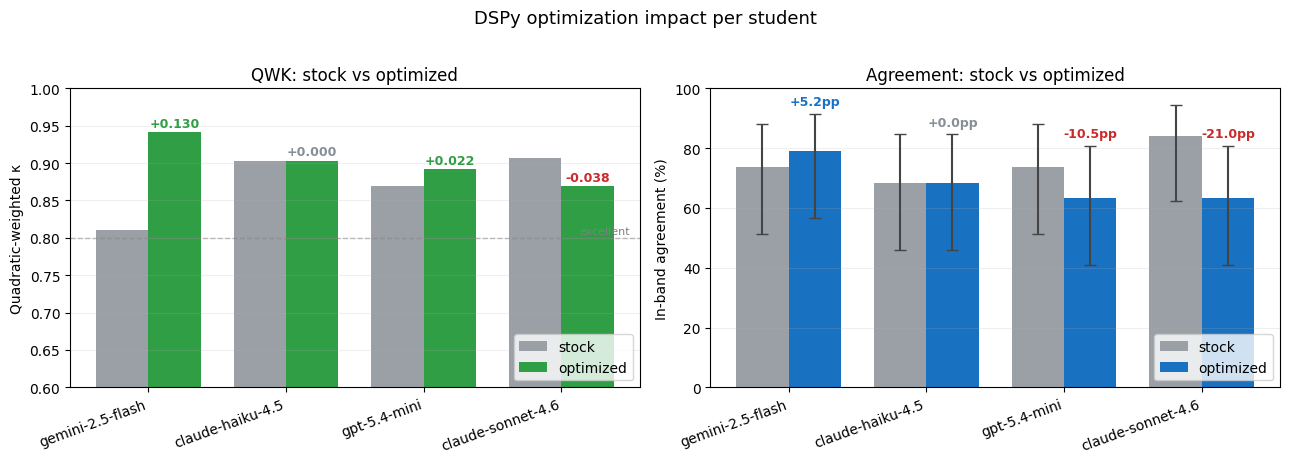

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = sweep.reset_index()
plot_df["short"] = plot_df["student"].str.split("/").str[-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
x = np.arange(len(plot_df))
width = 0.38

# QWK
ax = axes[0]
b1 = ax.bar(x - width/2, plot_df["qwk_pre"],  width, label="stock",     color="#9aa0a6")
b2 = ax.bar(x + width/2, plot_df["qwk_post"], width, label="optimized", color="#2f9e44")
for i, (pre, post) in enumerate(zip(plot_df["qwk_pre"], plot_df["qwk_post"])):
    delta = post - pre
    color = "#2f9e44" if delta > 0 else ("#c92a2a" if delta < 0 else "#868e96")
    ax.annotate(f"{delta:+.3f}", xy=(i + width/2, post), xytext=(0, 4),
                textcoords="offset points", ha="center", fontsize=9, color=color, fontweight="bold")
ax.axhline(0.8, color="grey", linestyle="--", linewidth=1, alpha=0.5)
ax.text(len(plot_df) - 0.5, 0.805, "excellent", color="grey", fontsize=8, ha="right")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["short"], rotation=20, ha="right")
ax.set_ylabel("Quadratic-weighted κ")
ax.set_ylim(0.6, 1.0)
ax.set_title("QWK: stock vs optimized")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.2)

# Agreement (with Wilson 95% CI error bars and McNemar significance stars)
ax = axes[1]
err_pre  = np.array([plot_df["agreement_pre"]  - plot_df["_lo_pre"],
                     plot_df["_hi_pre"]  - plot_df["agreement_pre"]])
err_post = np.array([plot_df["agreement_post"] - plot_df["_lo_post"],
                     plot_df["_hi_post"] - plot_df["agreement_post"]])
b1 = ax.bar(x - width/2, plot_df["agreement_pre"],  width, label="stock",     color="#9aa0a6",
            yerr=err_pre,  capsize=4, ecolor="#444")
b2 = ax.bar(x + width/2, plot_df["agreement_post"], width, label="optimized", color="#1971c2",
            yerr=err_post, capsize=4, ecolor="#444")
for i, row in plot_df.iterrows():
    delta = row["agreement_post"] - row["agreement_pre"]
    color = "#1971c2" if delta > 0 else ("#c92a2a" if delta < 0 else "#868e96")
    star = "*" if row["mcnemar_p"] < 0.05 else ""
    label = f"{delta:+.1f}pp{star}"
    # Place annotation above the upper CI bar so it doesn't collide with whiskers.
    y_top = max(row["_hi_post"], row["agreement_post"])
    ax.annotate(label, xy=(i + width/2, y_top), xytext=(0, 6),
                textcoords="offset points", ha="center", fontsize=9, color=color, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["short"], rotation=20, ha="right")
ax.set_ylabel("In-band agreement (%)")
ax.set_ylim(0, 100)
ax.set_title("Agreement: stock vs optimized")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.2)

fig.suptitle("DSPy optimization impact per student", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Reading the output

- `headline` — overall test-set agreement, before vs. after. **This is the number to put on a slide.**
- **Significance check (paired 2×2 + Wilson CIs + exact McNemar)** — the headline delta means very little without it. Look at the discordant cells `b` (regressions) and `c` (fixes): McNemar tests *only* those, because concordant items carry no information about the difference between variants. Three patterns to recognize:
  1. `c >> b` and `p < 0.05` → real win. The optimizer is fixing items the baseline missed, not just shuffling.
  2. `c ≈ b` (even if accuracy nominally rose) → the optimizer traded one set of errors for another. Headline gain is noise.
  3. `b + c` very small → underpowered. You can't conclude anything; grow the gold set or accept that the test is inconclusive. The Wilson CIs on each variant make this concrete — if they overlap heavily, the paired test is your only hope of detecting a real effect.
- `by_probe.delta` — per-probe agreement change. The wins we want are on `honesty_vs_fabrication` and `refusal_mode_equivalence`. A loss on `format_vs_verbosity` is acceptable (we down-weighted it on purpose) — those probes test whether the judge can *ignore* form, which is a harder property to teach with prompt optimization alone.
- `detail` — per-item scores. Look for items that flipped red→green (fixed by optimizer) and green→red (regressions).

## If we see no movement

Probable causes, in order of likelihood:
1. **Gold set too small for this optimizer.** 16 train items leaves very little for the random search to grip on. Grow the gold set first (target ~60-80 items) before turning more knobs.
2. **Metric is too coarse.** Smooth-distance treats a 0.5-point miss the same as a 0.49-point miss. Try a continuous version (`exp(-dist^2)`) or weight by which judge dimension was wrong (correctness/faithfulness, not just overall).
3. **Student model lacks headroom.** A `gpt-5.4-mini`-as-judge has a ceiling. Switch to `claude-sonnet-4.6` or `gpt-5.4` and re-run.
4. **Wrong optimizer.** Try `MIPROv2` (jointly searches instructions + demos via Bayesian-ish inner loop). Slower and pricier, but stronger when you have enough train items to feed it.

## If we see big movement

Be suspicious. With 16 train items, it's easy to overfit to band edges. Convince yourself the gain holds by:
1. Growing the gold set and re-splitting; rerun the optimizer; check the gain replicates.
2. Running the optimized prompt against a *new, unseen* set of 5-10 items you author after seeing the optimization output (a true held-out set, not a held-out split).
3. Eyeballing the few-shot demos the optimizer kept (`save-prompt` cell). If they look like sensible exemplars of the bias-correct behavior, the gain is probably real. If they look random or weirdly correlated, the optimizer found a shortcut.